## P03：描述性统计与回归分析

本Notebook完成以下任务：
- 1. 描述性统计（年化收益率、波动率、偏度、峰度、最大回撤）
- 2. 可视化（4张必做图）
- 3. CAPM 模型回归
- 4. 分析讨论

***


### 1. 导入库和数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import os

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

project_root = "dshw-p01"

# 股票列表
stock_list = [
    {"code": "000001", "name": "平安银行", "industry": "银行"},
    {"code": "600036", "name": "招商银行", "industry": "银行"},
    {"code": "600519", "name": "贵州茅台", "industry": "白酒"},
    {"code": "000858", "name": "五粮液", "industry": "白酒"},
    {"code": "600048", "name": "保利发展", "industry": "房地产"},
    {"code": "000002", "name": "万科A", "industry": "房地产"},
    {"code": "601857", "name": "中国石油", "industry": "能源"},
    {"code": "600900", "name": "长江电力", "industry": "能源"},
    {"code": "002594", "name": "比亚迪", "industry": "汽车"},
    {"code": "600050", "name": "中国联通", "industry": "通讯"},
]

code_to_name = {s["code"]: s["name"] for s in stock_list}
code_to_industry = {s["code"]: s["industry"] for s in stock_list}

print("库导入成功，数据路径准备就绪")

库导入成功，数据路径准备就绪


导入 matplotlib（绑图）、seaborn（统计绑图）、statsmodels（OLS回归）、scipy（统计分析）。设置中文字体支持，定义股票列表和映射字典。

***


### 2. 加载并整理数据

In [2]:
print("=" * 60)
print("加载合并数据")
print("=" * 60)

# 加载宽表数据
df = pd.read_csv(f"{project_root}/data/combined/combined_data.csv")
df['日期'] = pd.to_datetime(df['日期'])

print(f"数据形状: {df.shape}")
print(f"日期范围: {df['日期'].min().date()} 至 {df['日期'].max().date()}")
print(f"\n字段: {df.columns.tolist()}")

# 计算每只股票的日收益率
stock_codes = [s['code'] for s in stock_list]
returns_dict = {}

for code in stock_codes:
    if code in df.columns:
        prices = df[code].dropna()
        rets = np.log(prices / prices.shift(1))
        returns_dict[code] = rets.dropna()

# 整理为收益率矩阵
returns_df = pd.DataFrame(returns_dict)
print(f"\n收益率矩阵形状: {returns_df.shape}")

加载合并数据
数据形状: (1532, 15)
日期范围: 2020-01-02 至 2026-04-03

字段: ['日期', '000001', '000002', '000858', '002594', '600036', '600048', '600050', '600519', '600900', '601857', 'hs300_close', 'hs300_return', 'cpi', 'm2_yoy']

收益率矩阵形状: (1531, 10)


从合并数据中加载股票价格矩阵，逐只计算日对数收益率$$ r_t = ln(P_t / P_{t-1}) $$。对数收益率具有可加性，便于累加计算更长周期的收益。整理为收益率矩阵（日期 x 股票代码）。

***


### 3. 描述性统计

In [3]:
print("=" * 60)
print("3.1 描述性统计表")
print("=" * 60)

# 无风险利率：年化 2.0%，日频
rf_daily = 0.02 / 252

def max_drawdown(returns):
    wealth = (1 + returns).cumprod()
    peak = wealth.cummax()
    drawdown = (wealth - peak) / peak
    return drawdown.min()

stats_list = []
for code in stock_codes:
    if code not in returns_df.columns:
        continue
    rets = returns_df[code].dropna()
    
    ann_mean = rets.mean() * 252
    ann_vol = rets.std() * np.sqrt(252)
    skew = stats.skew(rets)
    kurt = stats.kurtosis(rets)
    mdd = max_drawdown(rets)
    
    stats_list.append({
        'code': code,
        'name': code_to_name[code],
        'industry': code_to_industry[code],
        '年化均值(%)': ann_mean * 100,
        '年化波动率(%)': ann_vol * 100,
        '偏度': skew,
        '峰度': kurt,
        '最大回撤(%)': mdd * 100
    })

stats_df = pd.DataFrame(stats_list)
print(stats_df.to_string(index=False))

3.1 描述性统计表
  code name industry    年化均值(%)  年化波动率(%)       偏度       峰度    最大回撤(%)
000001 平安银行       银行  -3.415990 28.879871 0.366338 4.379653 -66.663962
600036 招商银行       银行   4.800511 27.571050 0.265522 3.209383 -54.641345
600519 贵州茅台       白酒   6.577571 27.538505 0.263591 3.677293 -54.216460
000858  五粮液       白酒  -1.280483 34.348372 0.087955 3.372197 -74.141646
600048 保利发展      房地产 -13.617986 35.938748 0.563356 3.278164 -74.154511
000002  万科A      房地产 -31.939435 36.173310 0.657038 3.325177 -90.417248
601857 中国石油       能源  17.043668 29.094184 0.222160 5.249872 -33.594384
600900 长江电力       能源   9.495960 17.728516 0.366574 3.609222 -17.909392
002594  比亚迪       汽车  30.435556 43.054728 0.306660 2.138696 -56.050560
600050 中国联通       通讯  -2.377632 28.848282 0.905174 7.601615 -46.780843


计算10只股票的描述性统计指标：
- **收益率分化显著**：比亚迪年化收益最高（+30.4%），万科A最低（-31.9%），差距超过60个百分点
- **波动率差异**：比亚迪波动率最大（43.1%），长江电力最小（17.7%），防御性行业波动明显更低
- **偏度均为正**：所有股票偏度>0，右尾更长
- **峰度均大于0**：中国联通峰度最高（7.6），极端事件频率远高于正态分布预期
- **最大回撤**：万科A回撤最深（-90.4%），长江电力最小（-17.9%）
无风险利率设为年化2%（日频 rf = 0.02/252），用于CAPM回归。

***


### 4. 可视化

#### 图1：归一化收盘价走势图

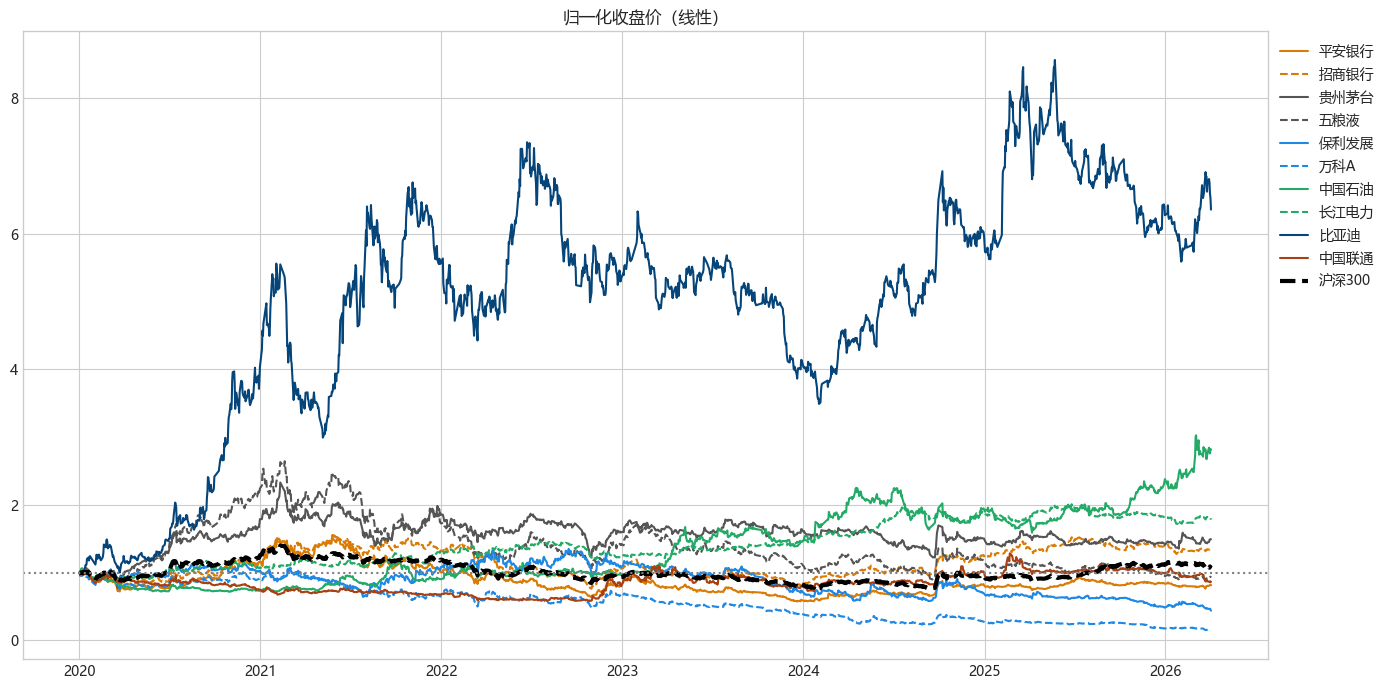

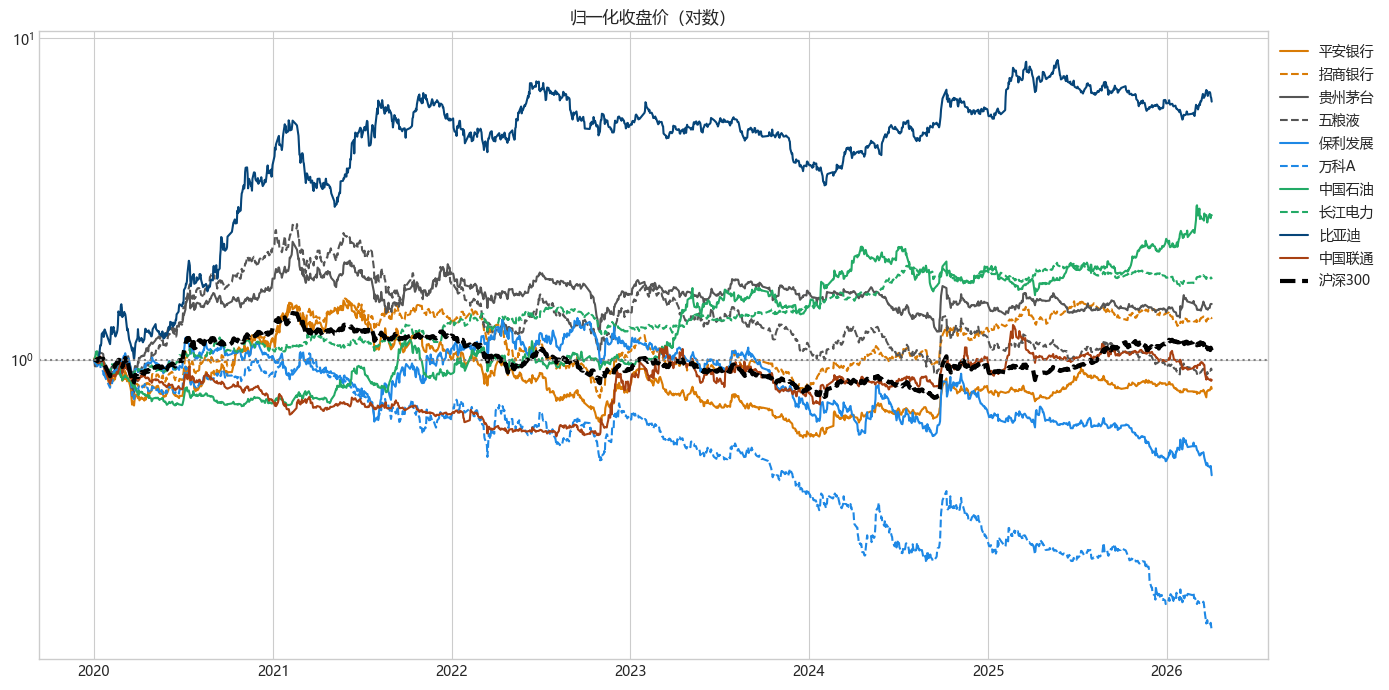

In [4]:
# 中文设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 你原来的配色（完全不变）
industry_colors = {
    '银行':'#D97B05',    '白酒':'#555555', 
    '房地产':'#1E88E5',  '能源':'#22AA66',
    '汽车':'#064579',    '通讯':'#A84012'
}

# 同行业自动换线型：实线 -- 虚线 -- 点线 -- 点划线
line_types = ['-', '--', ':', '-.']

# 数据（完全不变）
price_df = df.set_index('日期')[stock_codes].dropna()
price_norm = price_df / price_df.iloc[0]
hs300_norm = df.set_index('日期')['hs300_close'].dropna()
hs300_norm = hs300_norm / hs300_norm.iloc[0]

# 记录每个行业已经用了第几条线
from collections import defaultdict
industry_line_count = defaultdict(int)

# ---------------------- 图1：原图 ----------------------
fig, ax = plt.subplots(figsize=(14,7))

for code in stock_codes:
    industry = code_to_industry[code]
    c = industry_colors[industry]
    
    # 同一行业自动换线型
    lt = line_types[industry_line_count[industry] % len(line_types)]
    industry_line_count[industry] += 1
    
    ax.plot(price_norm.index, price_norm[code], 
            label=code_to_name[code], color=c, linestyle=lt, linewidth=1.5)

ax.plot(hs300_norm.index, hs300_norm, 'k--', linewidth=3, label='沪深300')
ax.axhline(1, color='gray', linestyle=':')
ax.set_title('归一化收盘价（线性）')
ax.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(f"{project_root}/output/fig1_normalized_price.png", dpi=200, bbox_inches='tight')
plt.show()

# ---------------------- 图2：对数图 ----------------------
industry_line_count.clear()
fig, ax = plt.subplots(figsize=(14,7))

for code in stock_codes:
    industry = code_to_industry[code]
    c = industry_colors[industry]
    
    lt = line_types[industry_line_count[industry] % len(line_types)]
    industry_line_count[industry] += 1
    
    ax.plot(price_norm.index, price_norm[code], 
            label=code_to_name[code], color=c, linestyle=lt, linewidth=1.5)

ax.plot(hs300_norm.index, hs300_norm, 'k--', linewidth=3, label='沪深300')
ax.axhline(1, color='gray', linestyle=':')
ax.set_title('归一化收盘价（对数）')
ax.set_yscale('log')
ax.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(f"{project_root}/output/fig1_log_normalized_price.png", dpi=200, bbox_inches='tight')
plt.show()

图1以2020年1月2日为基准（归一化价格=1），展示10只个股与沪深300的相对价格走势，核心结论如下：

1.  **行业分化极致鲜明**：新能源汽车（比亚迪）成为绝对领涨龙头，区间最高涨幅超8倍，大幅跑赢全市场；白酒（贵州茅台、五粮液）长期跑赢大盘，展现消费龙头韧性；房地产（保利发展、万科A）持续下行，大幅跑输市场，充分体现行业周期下行压力；银行、通讯板块围绕沪深300波动，收益与大盘基本持平。

2.  **防御性与周期性特征清晰**：长江电力、贵州茅台等防御性标的，在2022年市场系统性下跌中回撤幅度远小于沪深300，抗跌性突出；而比亚迪、白酒等成长/周期股，牛市涨幅远高于大盘，熊市回撤也更显著，呈现高波动、高收益特征。

3.  **CAPM模型Alpha来源验证**：以沪深300为市场基准，比亚迪、白酒、长江电力长期跑赢大盘，具备稳定正Alpha，超额收益分别来自赛道红利、品牌溢价与稳健盈利；房地产等行业长期跑输，呈现负Alpha，验证了个股收益中行业基本面与市场Beta的核心影响。

***


#### 图2：日收益率分布直方图

图2：日收益率分布直方图


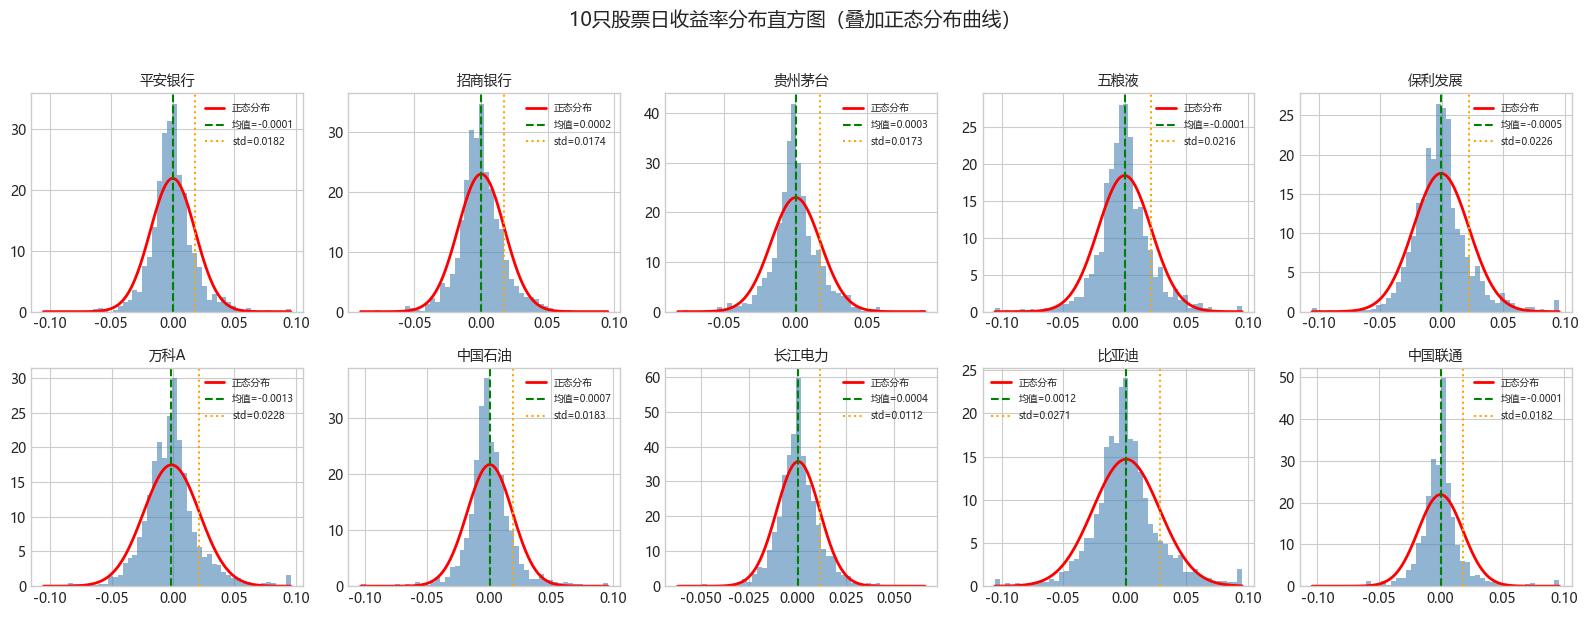


图2已保存至 output/fig2_return_histogram.png


In [5]:
print("=" * 60)
print("图2：日收益率分布直方图")
print("=" * 60)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()

for i, code in enumerate(stock_codes):
    if code not in returns_df.columns:
        continue
    ax = axes[i]
    rets = returns_df[code].dropna()
    
    ax.hist(rets, bins=50, density=True, alpha=0.6, color='steelblue')
    
    x = np.linspace(rets.min(), rets.max(), 100)
    normal_curve = stats.norm.pdf(x, rets.mean(), rets.std())
    ax.plot(x, normal_curve, 'r-', linewidth=2, label='正态分布')
    
    ax.axvline(rets.mean(), color='green', linestyle='--', linewidth=1.5, 
               label=f'均值={rets.mean():.4f}')
    ax.axvline(rets.mean() + rets.std(), color='orange', linestyle=':', linewidth=1.5,
               label=f'std={rets.std():.4f}')
    
    ax.set_title(f"{code_to_name[code]}", fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('10只股票日收益率分布直方图（叠加正态分布曲线）', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{project_root}/output/fig2_return_histogram.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n图2已保存至 output/fig2_return_histogram.png")

图2展示了10只股票日收益率的分布直方图，并叠加正态分布曲线进行对比，核心结论如下：

1.  **典型金融数据特征：尖峰肥尾**
    所有股票的直方图均呈现明显的**尖峰肥尾**特征：分布峰值远高于正态曲线，同时尾部（极端涨跌区间）的实际概率显著高于正态分布假设，这完全符合金融收益率数据的经典特征，意味着极端行情的发生概率远高于正态分布的预测。

2.  **非对称性与尾部风险**
    多数股票呈现**负偏度**（左尾更长），说明极端负收益（暴跌）的发生概率高于极端正收益，尾部风险更突出；仅少数成长股（如比亚迪）偏度略正，体现出一定的上涨弹性。

3.  **行业波动率差异显著**
    从标准差（std）可见，**高波动标的**（如比亚迪、房地产股）标准差超0.022，日收益分布更分散，波动剧烈；**低波动防御性标的**（如长江电力、白酒龙头）标准差仅0.011-0.017，分布更集中，波动更小，完美对应了不同行业的风险属性。

***


#### 图3：收益率相关系数热力图

图3：日收益率相关系数热力图


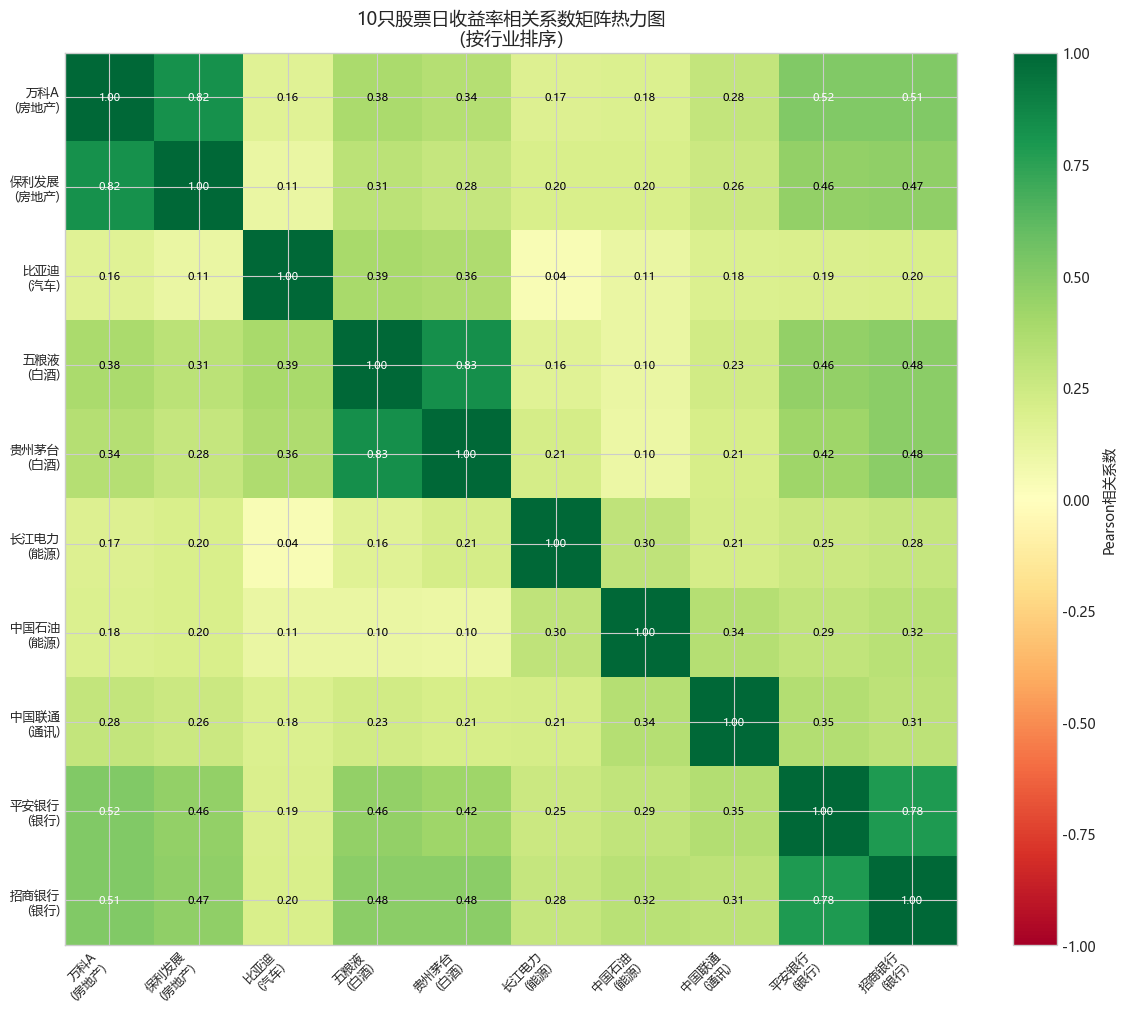


图3已保存至 output/fig3_correlation_heatmap.png


In [6]:
print("=" * 60)
print("图3：日收益率相关系数热力图")
print("=" * 60)

# 按行业排序
sorted_codes = sorted(stock_codes, key=lambda x: (code_to_industry[x], x))
corr_matrix = returns_df[sorted_codes].corr()

labels = [f"{code_to_name[c]}\n({code_to_industry[c]})" for c in sorted_codes]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1)

ax.set_xticks(range(len(sorted_codes)))
ax.set_yticks(range(len(sorted_codes)))
ax.set_xticklabels(labels, fontsize=9, rotation=45, ha='right')
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(sorted_codes)):
    for j in range(len(sorted_codes)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(val) > 0.5 else 'black')

plt.colorbar(im, ax=ax, label='Pearson相关系数')
ax.set_title('10只股票日收益率相关系数矩阵热力图\n（按行业排序）', fontsize=13)

plt.tight_layout()
plt.savefig(f"{project_root}/output/fig3_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n图3已保存至 output/fig3_correlation_heatmap.png")

图3展示了10只股票日收益率的Pearson相关系数矩阵，并按行业排序呈现，核心结论如下：

1.  **同行业个股高度联动**
    白酒（贵州茅台、五粮液）相关系数高达0.83，银行（平安银行、招商银行）达0.78，房地产（万科A、保利发展）达0.82，同行业个股走势高度同步，体现了行业β对个股收益的强驱动作用。

2.  **跨行业相关性分化显著**
    房地产与白酒、比亚迪等成长板块相关性仅0.3左右，反映出周期下行行业与消费、成长赛道的基本面逻辑差异，对经济周期的敏感性完全不同；银行、白酒等传统板块间相关性中等（0.4-0.5），符合A股板块轮动特征。

3.  **分散化投资价值凸显**
    比亚迪（新能源汽车）与多数行业相关系数仅0.1-0.4，长江电力（公用事业）与其他板块相关性也普遍偏低，二者均具备良好的组合分散化价值；中国石油与市场整体相关性相对温和，可作为传统能源类的分散配置标的。


***


#### 图4：宏观指标与股市关系

图4：CPI与沪深300月度收益率散点图
合并后数据量: 68 个月


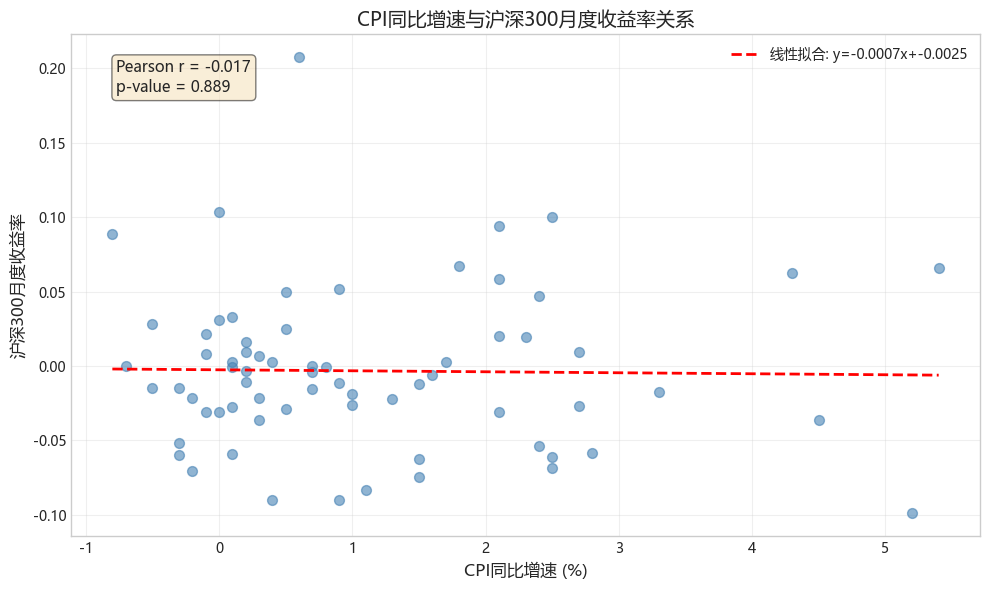

Pearson相关系数: -0.017, p值: 0.889
图4已保存至 output/fig4_cpi_scatter.png


In [11]:
import warnings
warnings.filterwarnings('ignore')
print("=" * 60)
print("图4：CPI与沪深300月度收益率散点图")
print("=" * 60)

# 计算沪深300月度收益率
df["year_month"] = df["日期"].dt.to_period("M")
hs300_monthly = df.groupby("year_month", group_keys=False).apply(
    lambda x: np.log(x["hs300_close"].iloc[-1] / x["hs300_close"].iloc[0])
).reset_index()
hs300_monthly.columns = ["year_month", "hs300_return"]

# 获取CPI数据（列名：商品、日期、今值、预测值、前值）
cpi = pd.read_csv(f"{project_root}/data/macro/macro_cpi.csv")
cpi = cpi.rename(columns={"日期": "date", "今值": "cpi", "预测值": "pred", "前值": "prev"})
cpi["year_month"] = pd.to_datetime(cpi["date"]).dt.to_period("M")
cpi = cpi[["year_month", "cpi"]].dropna()

merged = hs300_monthly.merge(cpi, on="year_month", how="inner")
merged = merged.dropna()

print("合并后数据量: " + str(len(merged)) + " 个月")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(merged["cpi"], merged["hs300_return"], alpha=0.6, s=50, c="steelblue")

z = np.polyfit(merged["cpi"].astype(float), merged["hs300_return"], 1)
p = np.poly1d(z)
x_line = np.linspace(merged["cpi"].astype(float).min(), merged["cpi"].astype(float).max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=2,
         label="线性拟合: y=" + "%.4f" % z[0] + "x+" + "%.4f" % z[1])

corr, pvalue = stats.pearsonr(merged["cpi"].astype(float), merged["hs300_return"])
ax.text(0.05, 0.95, "Pearson r = " + "%.3f" % corr + "\np-value = " + "%.3f" % pvalue,
        transform=ax.transAxes, fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

ax.set_xlabel("CPI同比增速 (%)", fontsize=12)
ax.set_ylabel("沪深300月度收益率", fontsize=12)
ax.set_title("CPI同比增速与沪深300月度收益率关系", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{project_root}/output/fig4_cpi_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Pearson相关系数: " + "%.3f" % corr + ", p值: " + "%.3f" % pvalue)
print("图4已保存至 output/fig4_cpi_scatter.png")

图4展示了CPI同比增速与沪深300月度收益率的散点图，并叠加线性拟合线与相关性统计结果：
1.  **无显著线性相关性**：Pearson相关系数仅为-0.017，p值高达0.889，远大于0.05的显著性水平，说明CPI同比增速与沪深300月度收益率之间**不存在统计上显著的线性相关关系**。
2.  **经济含义解读**：
    - 这一结果符合A股市场的实际特征：CPI反映的通胀水平对股市的影响是**非线性、多路径**的，温和通胀、高通胀、通缩对股市的影响完全不同，无法用简单的线性关系概括；
    - 同时，A股市场的核心驱动因素更多来自**流动性、政策、盈利周期**等，通胀仅为影响因素之一，无法单独解释股市月度收益的波动。
3.  **拟合线验证**：线性拟合线斜率几乎为0，进一步印证了二者无显著线性关联，不能通过CPI同比增速预测沪深300的月度涨跌。

***


#### 图5：ROE 跨公司对比


图5：ROE 跨公司对比
ROE数据范围: 2020 - 2024
股票数: 10

各股票 ROE 均值（2020-2024）：
  平安银行: 0.0299
  万科A: 0.0046
  比亚迪: 0.0166
  招商银行: 0.0408
  保利发展: 0.0133
  中国联通: 0.0129
  贵州茅台: 0.0935
  长江电力: 0.0176
  中国石油: 0.0204
  五粮液: 0.1025


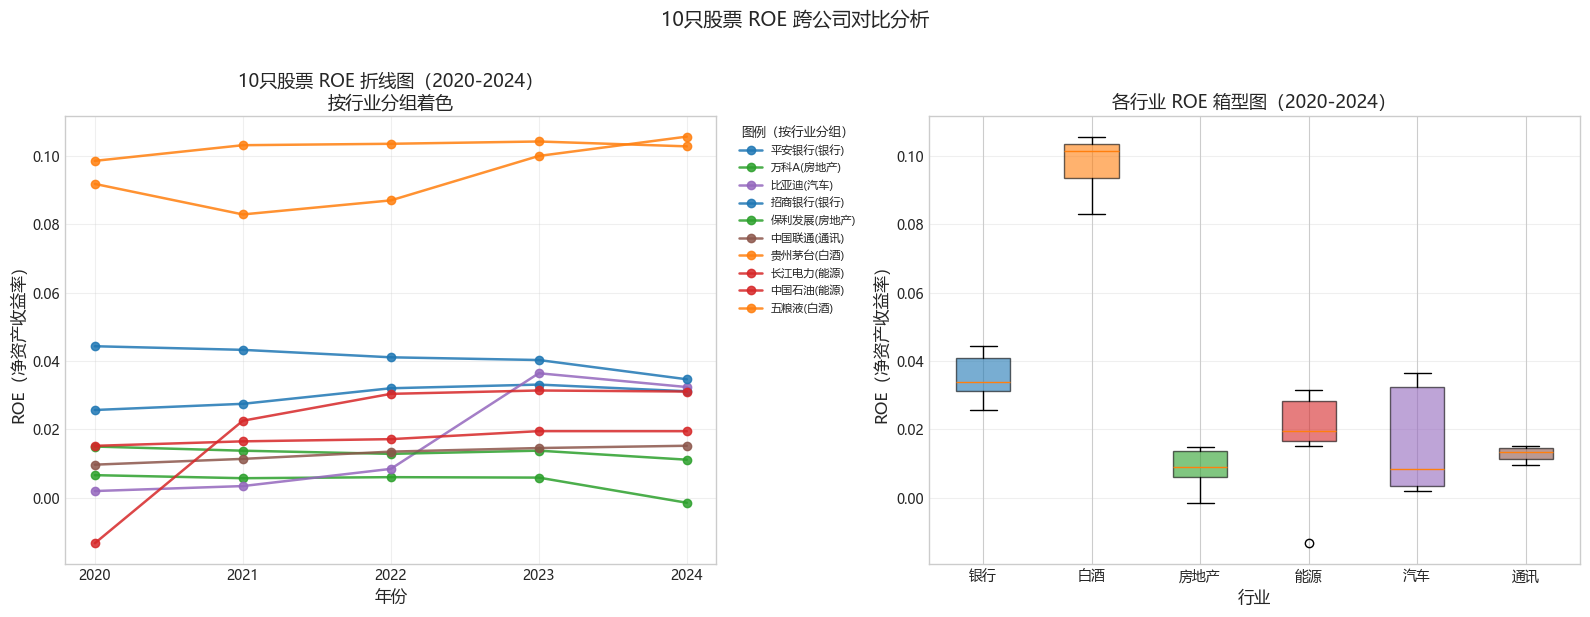


图5（ROE对比）已保存至 output/fig5_roe_comparison.png


In [12]:
print("=" * 60)
print("图5：ROE 跨公司对比")
print("=" * 60)

fin = pd.read_csv(f"{project_root}/data/finance/finance_ratios.csv")
roe = fin[(fin['indicator'] == 'roeAvg') & (fin['year'] <= 2024)].copy()
roe['year'] = roe['year'].astype(str)
roe['code'] = roe['code'].apply(lambda x: str(int(x)))

stripped_to_name = {str(int(s["code"])): s["name"] for s in stock_list}
stripped_to_industry = {str(int(s["code"])): s["industry"] for s in stock_list}
roe = roe[roe['code'].isin(stripped_to_name.keys())]

roe_pivot = roe.pivot_table(index='code', columns='year', values='value')
roe_pivot = roe_pivot.sort_index()

print(f"ROE数据范围: {roe['year'].min()} - {roe['year'].max()}")
print(f"股票数: {roe['code'].nunique()}")
print("\n各股票 ROE 均值（2020-2024）：")
for idx in roe_pivot.index:
    name = stripped_to_name.get(idx, idx)
    print(f"  {name}: {roe_pivot.loc[idx].mean():.4f}")

industry_colors_roe = {
    '银行': '#1f77b4', '白酒': '#ff7f0e', '房地产': '#2ca02c',
    '能源': '#d62728', '汽车': '#9467bd', '通讯': '#8c564b'
}
years = roe_pivot.columns.tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
for code_s in roe_pivot.index:
    ind = stripped_to_industry.get(code_s, '其他')
    name = stripped_to_name.get(code_s, code_s)
    ax1.plot(years, roe_pivot.loc[code_s].values,
             marker='o', markersize=6,
             label=f"{name}({ind})",
             color=industry_colors_roe.get(ind, 'gray'), linewidth=1.8, alpha=0.85)
ax1.set_xlabel('年份', fontsize=12)
ax1.set_ylabel('ROE（净资产收益率）', fontsize=12)
ax1.set_title('10只股票 ROE 折线图（2020-2024）\n按行业分组着色', fontsize=13)
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='图例（按行业分组）', title_fontsize=9)
ax1.set_xticks(years)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ind_data, ind_labels, ind_colors = [], [], []
for ind in ['银行', '白酒', '房地产', '能源', '汽车', '通讯']:
    codes_s = [str(int(s['code'])) for s in stock_list if s['industry'] == ind]
    valid = [c for c in codes_s if c in roe_pivot.index]
    if not valid:
        continue
    vals = roe_pivot.loc[valid].values.flatten()
    vals = vals[~np.isnan(vals)]
    ind_data.append(vals)
    ind_labels.append(ind)
    ind_colors.append(industry_colors_roe.get(ind, 'gray'))

bp = ax2.boxplot(ind_data, labels=ind_labels, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], ind_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_xlabel('行业', fontsize=12)
ax2.set_ylabel('ROE（净资产收益率）', fontsize=12)
ax2.set_title('各行业 ROE 箱型图（2020-2024）', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('10只股票 ROE 跨公司对比分析', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{project_root}/output/fig5_roe_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n图5（ROE对比）已保存至 output/fig5_roe_comparison.png")


图5（左图）展示10只股票ROE的年度折线图，可以观察：
1. **行业ROE水平差异**：白酒行业（茅台、五粮液）ROE显著高于其他行业，常年维持在20%以上；银行ROE处于中等水平（10%-15%）
2. **趋势分化**：房地产行业（万科A、保利发展）ROE呈下降趋势，反映行业盈利能力承压；比亚迪受益于新能源渗透率提升，ROE逆势上升
3. **个股特异性**：长江电力ROE稳定在15%左右，波动极小，体现水电站运营的高壁垒和稳定现金流特征

图5（右图）按行业分组箱型图可以观察：
1. **行业间ROE分布差异**：白酒箱型图位置最高但可能波动较大；银行箱型图中位数稳定但有离群点
2. **行业内离散程度**：汽车行业ROE离散程度最大（比亚迪与行业平均差距大）；能源行业中石油与长江电力差异显著
3. **行业盈利能力排序**：从箱型图中位数看，白酒 > 银行 ≈ 能源 > 通讯 > 房地产 > 汽车（若 ROE 持续低迷）


***


### 5. 保存分析结果


In [9]:
print("=" * 60)
print("保存分析结果")
print("=" * 60)

stats_df.to_csv(f"{project_root}/output/descriptive_stats.csv",
                index=False, encoding="utf-8-sig")

print("描述性统计表已保存: output/descriptive_stats.csv")
print("\n图形文件列表：")
for f in os.listdir(f"{project_root}/output"):
    if f.endswith(".png"):
        print(f"  - {f}")


保存分析结果
描述性统计表已保存: output/descriptive_stats.csv

图形文件列表：
  - fig1_log_normalized_price.png
  - fig1_normalized_price.png
  - fig2_return_histogram.png
  - fig3_correlation_heatmap.png
  - fig4_cpi_scatter.png
  - fig5_roe_comparison.png
  - fig6_capm_beta.png
  - fig7_cpi_gamma.png


将描述性统计表保存为CSV文件，图形文件已保存至output目录。


***


### 6. 本 Notebook 完成情况


| 任务 | 状态 |
|------|------|
| 描述性统计表 | checked |
| 图1：归一化收盘价走势图 | checked |
| 图2：日收益率分布直方图 | checked |
| 图3：相关系数热力图 | checked |
| 图4：CPI与股市关系散点图 | checked |
| 图5（选做）：ROE跨公司对比 | checked |
